In [1]:
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.signal import resample, resample_poly, butter, sosfiltfilt
import matplotlib.pyplot as plt
import cv2

import sys
import os
import yaml
import pickle
import h5py
from contextlib import redirect_stdout, redirect_stderr
from tqdm import tqdm


import utils as u
np.set_printoptions(suppress=True)

# Processing

In [2]:
mouse = 'mouse1'
session = '20240731_SG4311'

data_dir = f'../data/from Danai/{mouse}'

with open(f'{data_dir}/{session}.yaml', 'r') as f:
    session_meta = yaml.safe_load(f)
grating_recs = session_meta['recordings']['SG4311']['fovs'][0]['recGroups']['stim']['recs']
movie_recs = session_meta['recordings']['SG4311']['fovs'][0]['recGroups']['movie']['recs']
movie_recs.remove('A35')    # Remove problematic recording
print(movie_recs)

['A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50']


In [3]:
deltaf_fps = 40 # Hz
pupil_fps = 30 # Hz
stimuli_blocks = {
    'black_start': 4 * pupil_fps,
    'grey_start': 4 * pupil_fps,
    'movie': 60 * pupil_fps,
    'grey_end': 4 * pupil_fps,
    'black_end': 4 * pupil_fps,
}
cutoff_freq = [.01, .2]
plot = False

all_pupil = []
all_deltaf = []

for rec in tqdm(movie_recs, desc="Processing recordings"):
    with open(os.devnull, "w") as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            print("\n" + "="*40)
            print(f"Processing recording {rec}...")

            pupil_filepath = f'{data_dir}/pupil/SG4311/rest/{rec}DLC_mobnet_100_pupil_data_trainingNov12shuffle1_200000.csv'    
            deltaf_filepath = f'{data_dir}/Df/{session}/CaActivity/{rec}deltaf.mat'
            
            pupil, deltaf = u.load_and_preprocess_data(
                pupil_filepath,
                deltaf_filepath,
                stimuli_blocks,
                pupil_fps,
                deltaf_fps,
                cutoff_freq,
                plot
            )
            all_pupil.append(pupil)
            all_deltaf.append(deltaf)

all_pupil = np.concatenate(all_pupil, axis=0)
all_deltaf = np.concatenate(all_deltaf, axis=0)
print(f"Final concatenated data of all {len(movie_recs)} recordings:")
print("pupil:", all_pupil.shape)
print("deltaf:", all_deltaf.shape)


Processing recordings: 100%|██████████| 9/9 [00:05<00:00,  1.78it/s]

Final concatenated data of all 9 recordings:
pupil: (20529, 1)
deltaf: (20529, 186)


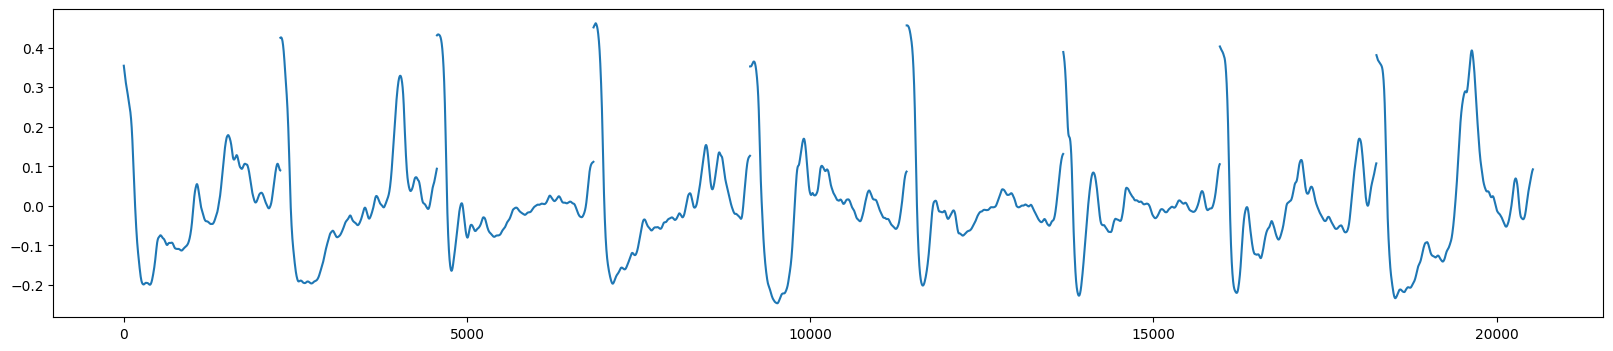

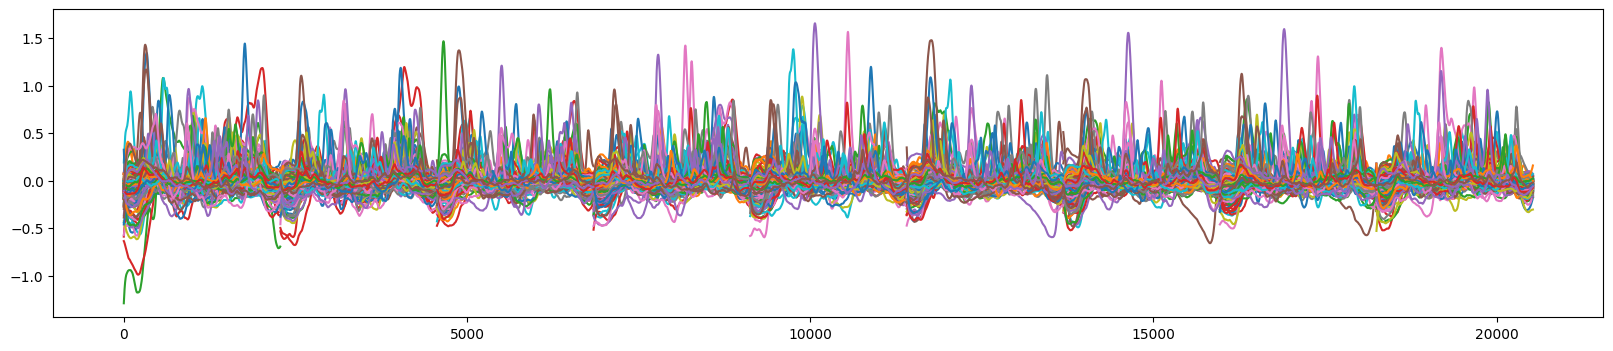

In [4]:
plt.figure(figsize=(20, 4))
plt.plot(all_pupil)
plt.show()
plt.figure(figsize=(20, 4))
plt.plot(all_deltaf)
plt.show()

# Model

In [5]:
import matplotlib.cm as cm
import tensorflow as tf
import keras
import numpy.matlib
import mat73
import colorcet as cc

from numpy import asarray
from scipy import stats, signal,io
from scipy.ndimage import median_filter as medfilt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.utils.extmath import randomized_svd as rsvd

from model_utils import tic, toc, hankel_matrix, scaler, legendre_polys, find_opt_lag, generate_color_gradient
from models import linear_regression, VAE

2026-01-15 16:09:26.337330: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-15 16:09:26.798994: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/andrew/miniconda3/envs/arousalenv/lib/python3.8/site-packages/cv2/../../lib64:
2026-01-15 16:09:26.799019: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-01-15 16:09:26.865751: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS wh

In [6]:
outdir = '../model_predictions/Danai/indiv'
os.makedirs(outdir, exist_ok=True)

# Set modeling parameters
subjects = ['mouse1']
modality = 'deltaf'

Fs = 30             # sampling frequency
dt = 1/Fs
nsamples = int(20529*0.7)     # num_frames used for training
gap = 100           # num_frames to leave out between train/test to avoid temporal correlations leakage
lag_range = 5       # range of lags (in seconds) to consider when finding optimal lag between pupil and deltaF


# (delay, nonlinear) combos
# Delay: 1 = optimal lag applied, 0 = no lag
# Nonlinear: 1 = VAE model, 0 = linear model
configs = [(1, 1), (1, 0), (0, 1), (0, 0)] 


# Hankel matrix parameters
stackmax = 5       # row dimension (i.e., number of time shifts)
spacing = 1         # number of samples separating each row
r = 6               # number of modes of the Hankel matrix to keep (used for projection onto top r Legendre polynomials)


# VAE parameters
z_n = 4             # number of latent dimensions used for VAE
num_epochs = 200    # number of training epochs
lr = .01            # learning rate
beta = 1            # beta weight for KL loss in VAE training
anneal_step = 200   # determines rate at which KL loss is increased during training
pretrained_enc = [] # pretrained encoder


In [8]:
for subj in subjects:
    
    tic()
    
    print(subj)
    # Load data
    x = all_pupil
    y = all_deltaf
    
    for mode in configs:
        # Get config (delay, nonlinear) 0 or 1
        delay, nonlinear = mode
    
        ## Train-test split
        test_size = x.shape[0] - nsamples
        xtrain, xtest, ytrain, ytest = train_test_split(
            x, y, test_size=test_size, shuffle=False
        )
        xtest = xtest[gap:, :]
        ytest = ytest[gap:, :]

        # Find lag that optimises cross-corelation between pupil and deltaF
        lag, _, _ = find_opt_lag(xtrain, np.nanmean(ytrain, axis=1), int(lag_range/dt))
        if lag:
            xtrain = xtrain[lag:, :]
            ytrain = ytrain[:-lag, :]
            xtest = xtest[lag:, :]
            ytest = ytest[:-lag, :]

        # ----------------------------------------------------------------------
        # Time delay embedding  
        # ----------------------------------------------------------------------
        # Construct Hankel matrices
        Hp_train = hankel_matrix(xtrain.T, stackmax, spacing)
        Hp_test = hankel_matrix(xtest.T, stackmax, spacing)

        # Project onto Legendre polynomials
        polys = legendre_polys(r, stackmax)
        xtrain = Hp_train.T @ polys
        xtest = Hp_test.T @ polys

        # Concatenate last row of Hankel matrix (i.e., original signal with max lag)
        xtrain = np.concatenate((xtrain, Hp_train.T[:, -1:]), axis=1)
        xtest = np.concatenate((xtest, Hp_test.T[:, -1:]), axis=1)

        # Mask rows (timepoints) that contain NaNs
        mask_nans_train = ~np.any(np.isnan(xtrain), axis=1)
        mask_nans_test = ~np.any(np.isnan(xtest), axis=1)
        xtrain = xtrain[mask_nans_train, :]
        xtest = xtest[mask_nans_test, :]

        # Apply the SAME row mask to y
        ytrain = ytrain[spacing * (stackmax-1):, :][mask_nans_train, :]
        ytest = ytest[spacing * (stackmax-1):, :][mask_nans_test, :]


        # ----------------------------------------------------------------------
        # Preprocessing
        # ----------------------------------------------------------------------
        # If no delay, only use current timepoint
        if not delay:
            xtrain = xtrain[:, -1:]
            xtest = xtest[:, -1:]
        # Standard Scaler    
        xtrain_sc, scale_x = scaler(xtrain)
        ytrain_sc, scale_y = scaler(ytrain)

        # ----------------------------------------------------------------------
        # Train model
        #----------------------------------------------------------------------
        if nonlinear:
            r_squared, model, encoder, decoder = VAE(
                xtrain_sc, 
                ytrain_sc, 
                latent_dim=z_n, 
                beta=beta,
                num_epochs=num_epochs, 
                anneal_step=anneal_step, 
                verbose=False
            )
        else:
            r_squared, model = linear_regression(xtrain_sc, ytrain_sc)

        #ytrain_hat_sc = model.predict(xtrain_sc)
        #ytrain_hat = scale_y.inverse_transform(ytrain_hat_sc)

        # ----------------------------------------------------------------------
        # Test model
        # ----------------------------------------------------------------------
        xtest_sc, _ = scaler(xtest, scale_x)

        ytest_hat_sc = model.predict(xtest_sc)
        ytest_hat = scale_y.inverse_transform(ytest_hat_sc)

        # ----------------------------------------------------------------------
        # Save files
        # ----------------------------------------------------------------------
        if delay & nonlinear:
            np.save(f"{outdir}/{str(subj)}_{modality}_delay_xtest.npy", xtest)
            np.save(f"{outdir}/{str(subj)}_{modality}_ytest.npy", ytest)
            np.save(f"{outdir}/{str(subj)}_{modality}_delay_nonlin_ytest_hat.npy", ytest_hat)
            encoder.save_weights(f"{outdir}/{str(subj)}_{modality}_delay_encoder_weights.h5")
            decoder.save_weights(f"{outdir}/{str(subj)}_{modality}_delay_decoder_weights.h5")
        elif delay:
            np.save(f"{outdir}/{str(subj)}_{modality}_delay_lin_ytest_hat.npy", ytest_hat)
        elif nonlinear:
            np.save(f"{outdir}/{str(subj)}_{modality}_nodelay_nonlin_ytest_hat.npy", ytest_hat)
        else:
            np.save(f"{outdir}/{str(subj)}_{modality}_nodelay_lin_ytest_hat.npy", ytest_hat)
            
    toc()

mouse1


/tmp/ipykernel_446692/3697593690.py:23: RuntimeWarning: Mean of empty slice
  lag, _, _ = find_opt_lag(xtrain, np.nanmean(ytrain, axis=1), int(lag_range/dt))
2026-01-15 16:09:38.014239: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/andrew/miniconda3/envs/arousalenv/lib/python3.8/site-packages/cv2/../../lib64:
2026-01-15 16:09:38.014356: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/andrew/miniconda3/envs/arousalenv/lib/python3.8/site-packages/cv2/../../lib64:
2026-01-15 16:09:38.014441: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot o

Elapsed time is 3.599337339401245 seconds.


/tmp/ipykernel_446692/3697593690.py:23: RuntimeWarning: Mean of empty slice
  lag, _, _ = find_opt_lag(xtrain, np.nanmean(ytrain, axis=1), int(lag_range/dt))


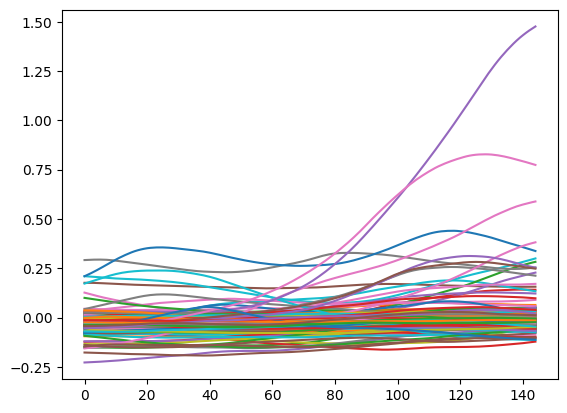

../model_predictions/Danai/indiv/mouse1_deltaf_nodelay_lin_ytest_hat.npy
(145, 186)


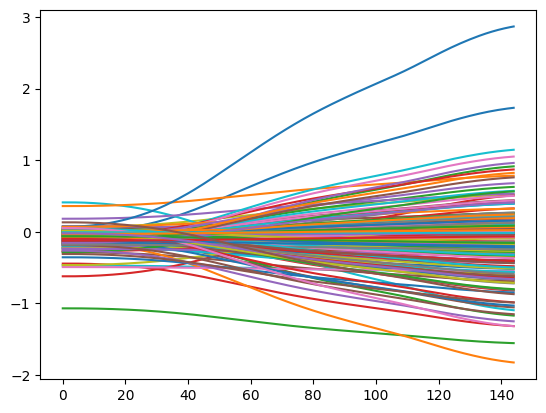

../model_predictions/Danai/indiv/mouse1_deltaf_nodelay_nonlin_ytest_hat.npy
(145, 186)


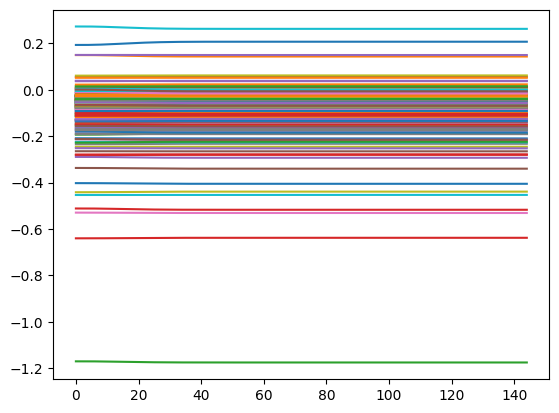

../model_predictions/Danai/indiv/mouse1_deltaf_delay_lin_ytest_hat.npy
(145, 186)


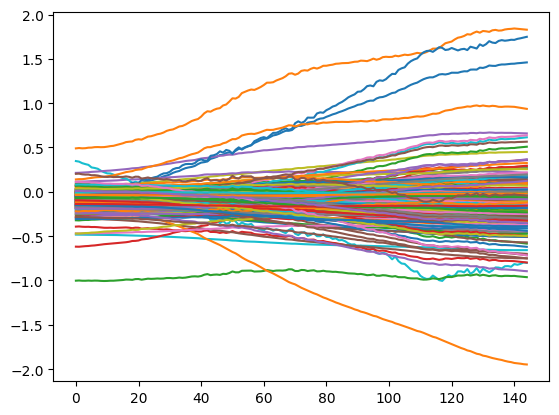

../model_predictions/Danai/indiv/mouse1_deltaf_delay_nonlin_ytest_hat.npy
(145, 186)


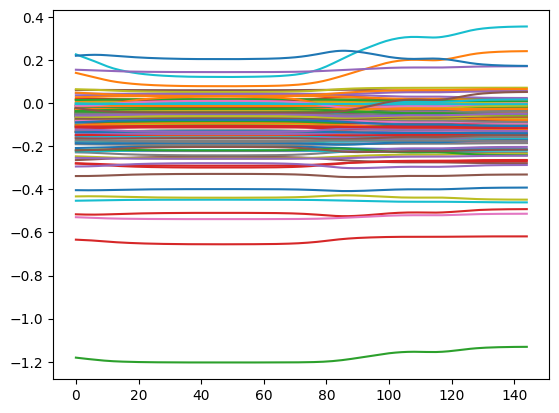

In [13]:
scores = np.zeros([len(subjects), 4])

paths = [
    f"{outdir}/{str(subj)}_{modality}_nodelay_lin_ytest_hat.npy",
    f"{outdir}/{str(subj)}_{modality}_nodelay_nonlin_ytest_hat.npy",
    f"{outdir}/{str(subj)}_{modality}_delay_lin_ytest_hat.npy",
    f"{outdir}/{str(subj)}_{modality}_delay_nonlin_ytest_hat.npy"
]

for s, subj in enumerate(subjects):
    ytest = np.load(f"{outdir}/{str(subj)}_{modality}_ytest.npy")
    plt.plot(ytest)
    plt.show()
    # Loop through results of each config
    for i, p in enumerate(paths):
        y_test_hat = np.load(p)
        scores[s, i] = r2_score(ytest, y_test_hat, multioutput = 'variance_weighted')

        print(p)
        print(y_test_hat.shape)
        plt.plot(y_test_hat)
        plt.show()

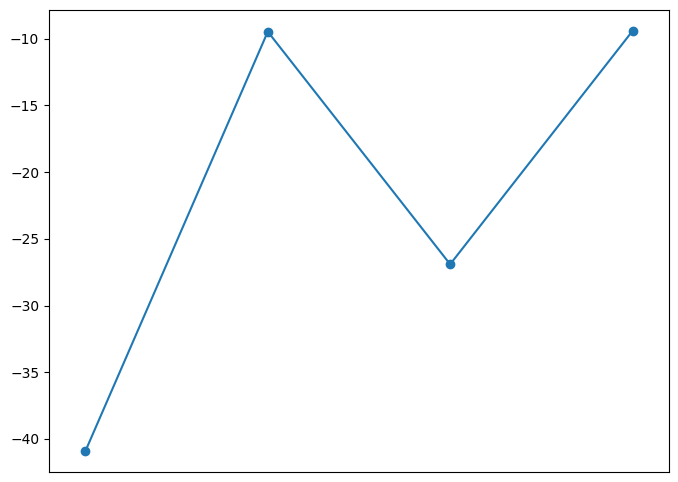

In [10]:
fig, ax = plt.subplots(figsize=(8,6))

for i in range(len(subjects)):
    plt.plot(scores[i,:].T,  markersize=12, marker = '.')
    
ax.set_xticks([])
ax.set_xlim([-.2,3.2])

# plt.savefig(figdir + '/r2_total_indv_' + modality + '_4way.pdf', dpi=300, transparent=True)

plt.show()

# Inspect Data

## Pupil Data

Raw DeepLabCut output: 2998 frames (or 99.93333333333334 seconds).
Laser on from frame 187 to 2880 for a duration of 2694 frames (or 89.8 seconds).
Stimuli (black/grey/movie): 2280 frames (or 76.0 seconds).


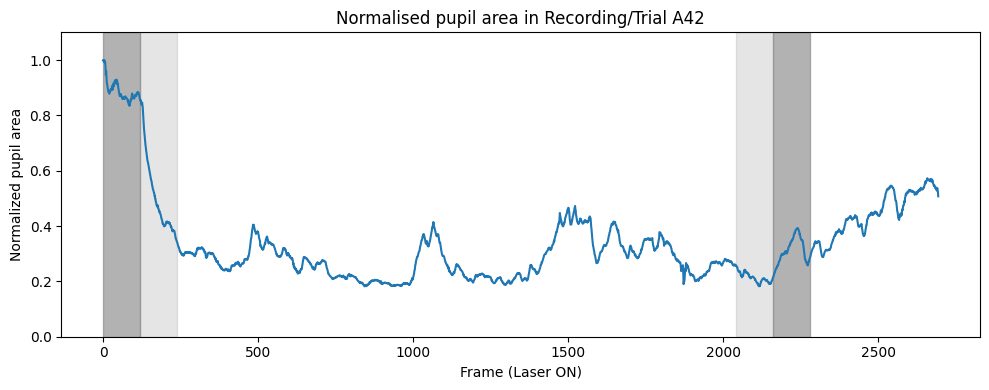

Raw DeepLabCut output: 2998 frames (or 99.93333333333334 seconds).
Laser on from frame 83 to 2776 for a duration of 2694 frames (or 89.8 seconds).
Stimuli (black/grey/movie): 2280 frames (or 76.0 seconds).


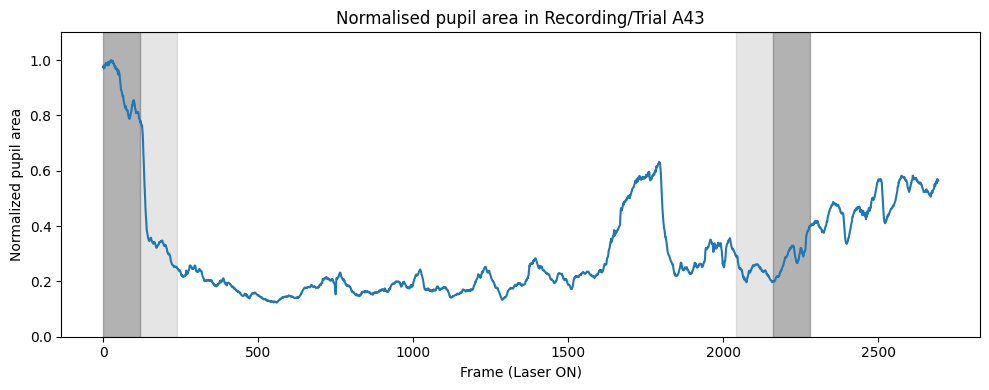

Raw DeepLabCut output: 2998 frames (or 99.93333333333334 seconds).
Laser on from frame 88 to 2782 for a duration of 2695 frames (or 89.83333333333333 seconds).
Stimuli (black/grey/movie): 2280 frames (or 76.0 seconds).


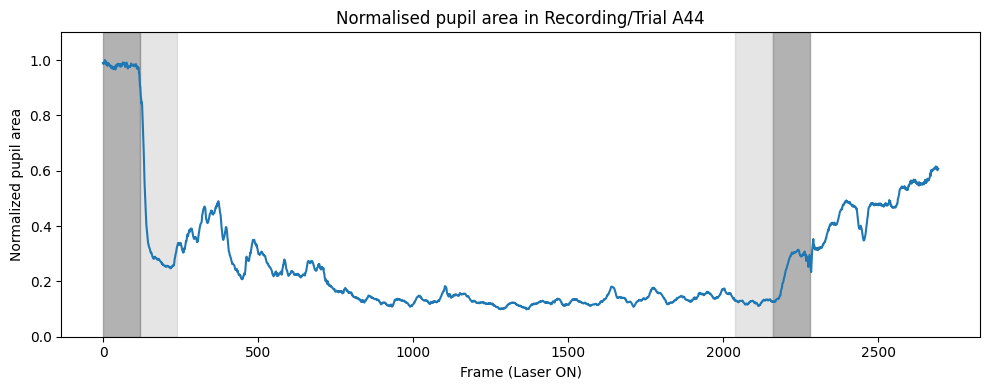

Raw DeepLabCut output: 2999 frames (or 99.96666666666667 seconds).
Laser on from frame 154 to 2848 for a duration of 2695 frames (or 89.83333333333333 seconds).
Stimuli (black/grey/movie): 2280 frames (or 76.0 seconds).


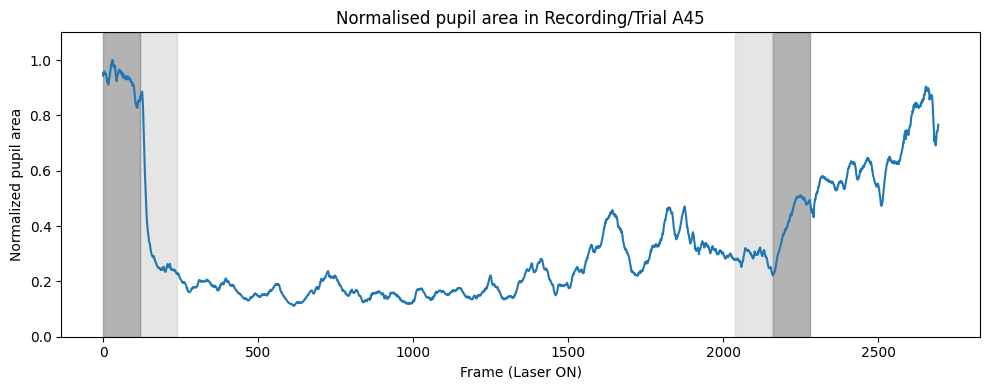

Raw DeepLabCut output: 2998 frames (or 99.93333333333334 seconds).
Laser on from frame 162 to 2856 for a duration of 2695 frames (or 89.83333333333333 seconds).
Stimuli (black/grey/movie): 2280 frames (or 76.0 seconds).


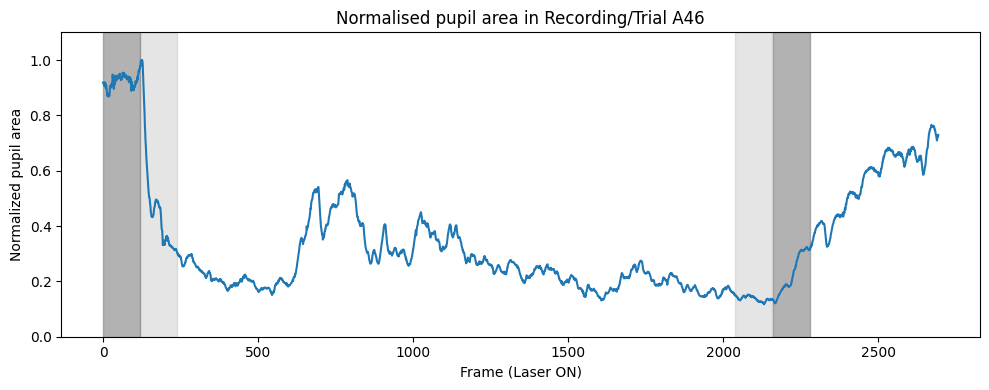

Raw DeepLabCut output: 2998 frames (or 99.93333333333334 seconds).
Laser on from frame 120 to 2813 for a duration of 2694 frames (or 89.8 seconds).
Stimuli (black/grey/movie): 2280 frames (or 76.0 seconds).


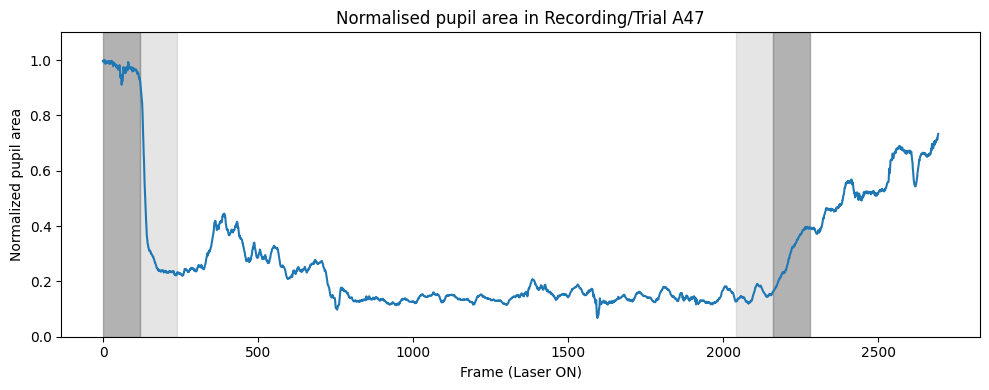

Raw DeepLabCut output: 2998 frames (or 99.93333333333334 seconds).
Laser on from frame 90 to 2784 for a duration of 2695 frames (or 89.83333333333333 seconds).
Stimuli (black/grey/movie): 2280 frames (or 76.0 seconds).


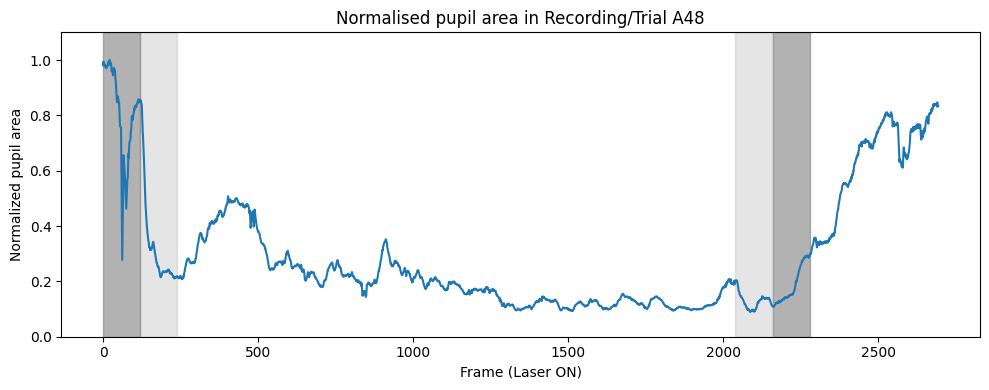

Raw DeepLabCut output: 2999 frames (or 99.96666666666667 seconds).
Laser on from frame 170 to 2863 for a duration of 2694 frames (or 89.8 seconds).
Stimuli (black/grey/movie): 2280 frames (or 76.0 seconds).


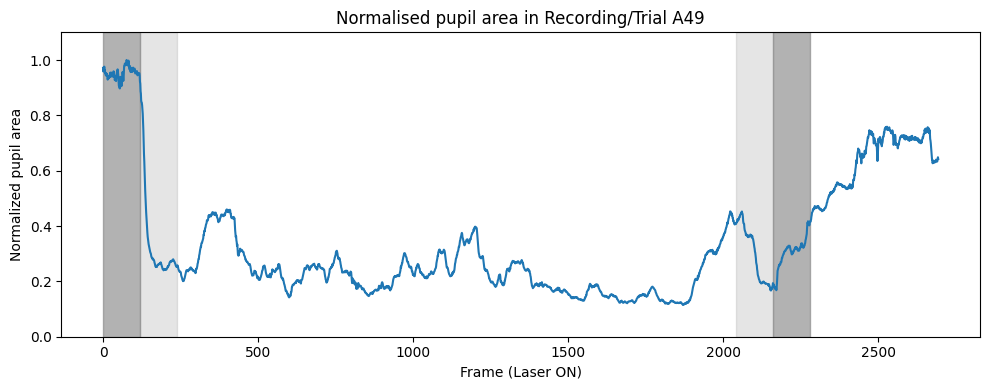

Raw DeepLabCut output: 2998 frames (or 99.93333333333334 seconds).
Laser on from frame 105 to 2798 for a duration of 2694 frames (or 89.8 seconds).
Stimuli (black/grey/movie): 2280 frames (or 76.0 seconds).


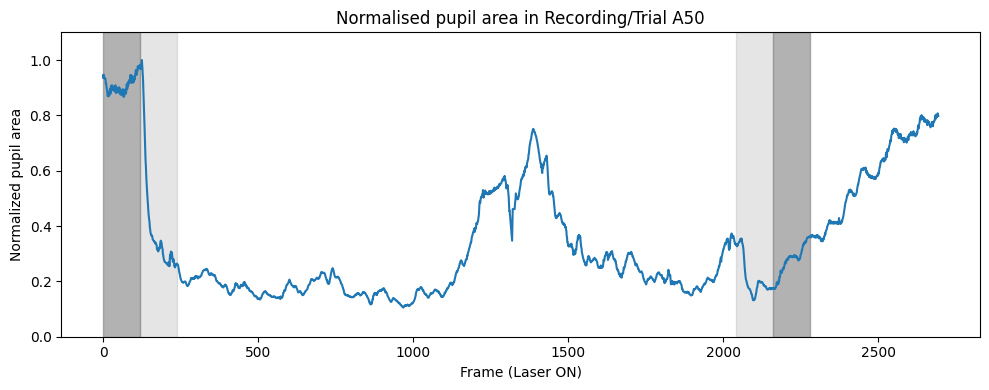

In [3]:
rec = 'A50'

for rec in movie_recs:
    filepath = f'{data_dir}/pupil/SG4311/rest/{rec}DLC_mobnet_100_pupil_data_trainingNov12shuffle1_200000.csv'
    pupil_df = u.get_pupil_data(filepath, stimuli_blocks, pupil_fps)

Raw DeepLabCut output: 2998 frames (or 99.93333333333334 seconds).
Laser on from frame 90 to 2784 for a duration of 2695 frames (or 89.83333333333333 seconds).
Stimuli (black/grey/movie): 2280 frames (or 76.0 seconds).


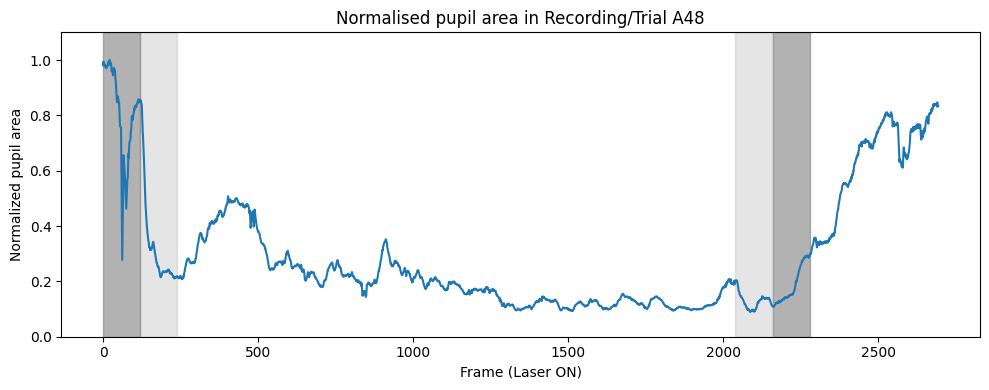

In [4]:
rec = 'A48'
filepath = f'{data_dir}/pupil/SG4311/rest/{rec}DLC_mobnet_100_pupil_data_trainingNov12shuffle1_200000.csv'
pupil_df = u.get_pupil_data(filepath, stimuli_blocks, pupil_fps)

In [5]:
display(pupil_df)
x = pupil_df['area'].values.astype(float)
print(x.shape)
print(x)

,frames,stimulus,area,norm_area
0,90,black_start,22817.915720,0.981698
1,91,black_start,23113.071573,0.994397
2,92,black_start,23058.877403,0.992065
3,93,black_start,22777.243170,0.979949
4,94,black_start,22930.756655,0.986553
...,...,...,...,...
2690,2780,None,19325.618886,0.831449
2691,2781,None,19681.769694,0.846772
2692,2782,None,19416.460065,0.835357
2693,2783,None,19365.156323,0.833150


(2695,)
[22817.91572049 23113.07157321 23058.87740311 ... 19416.4600653
 19365.15632337 19358.20714665]


### Method 1 using dx

(2695,)
[ 0.         72.87206444 79.23276169 ... 48.92675289 45.93090454
 42.0976229 ]
42.17633367223971
27.72438372187571
208.52263600349397
[False False False ... False False False]


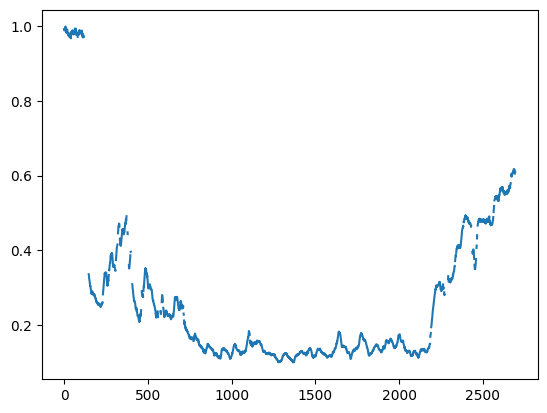

In [40]:
dx = np.abs(np.diff(x, prepend=x[0]))
print(dx.shape)
print(dx)

median_dx = np.median(dx)
mad_dx = np.median(np.abs(dx - median_dx))
print(median_dx)
print(mad_dx)

threshold = median_dx + 6 * mad_dx
print(threshold)

blink_idx = dx > threshold
print(blink_idx)

x[blink_idx] = np.nan

max_area = np.nanmax(x)

norm_areas = x / max_area

plt.plot(norm_areas)
plt.show()

### Method 2 using medfilt

3


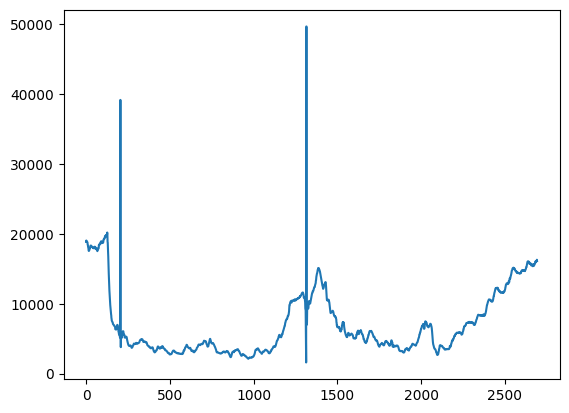

5


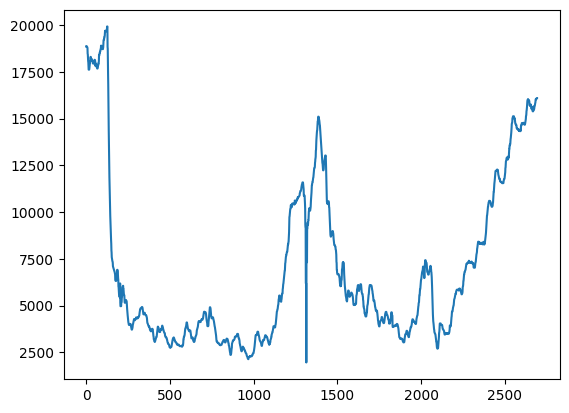

7


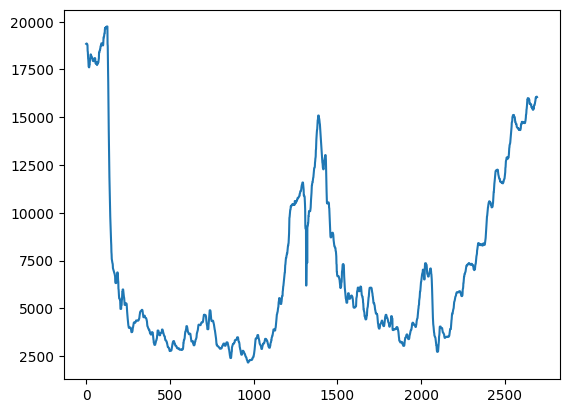

9


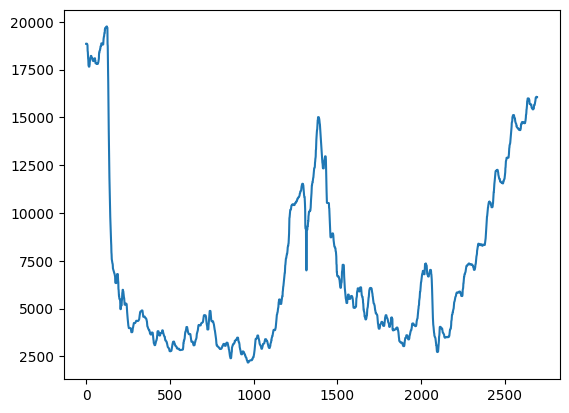

11


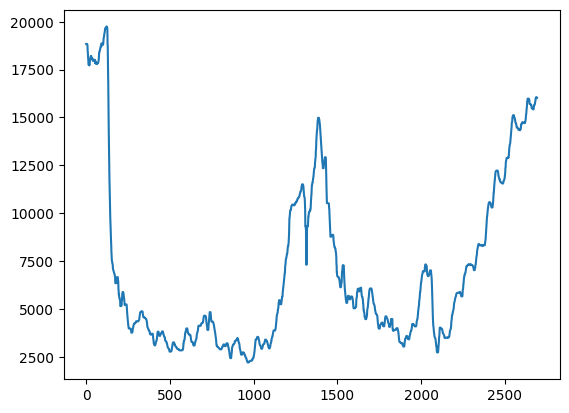

13


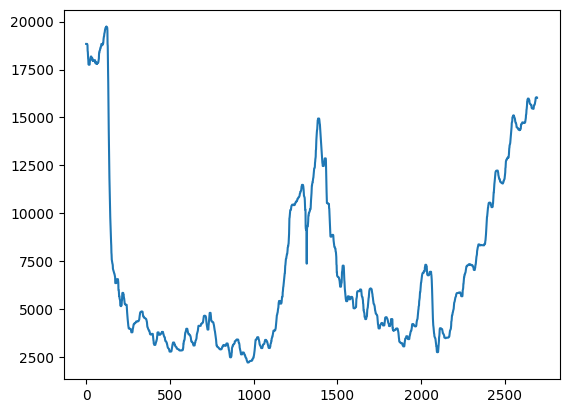

15


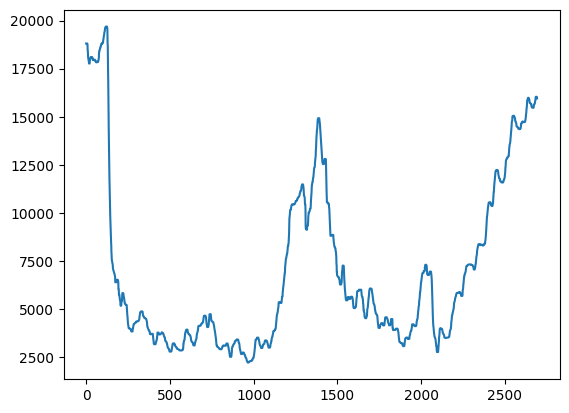

17


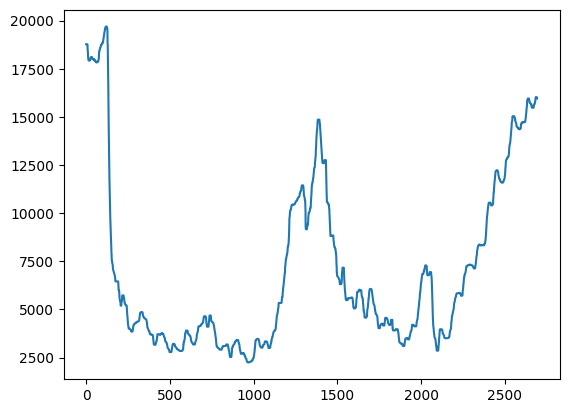

19


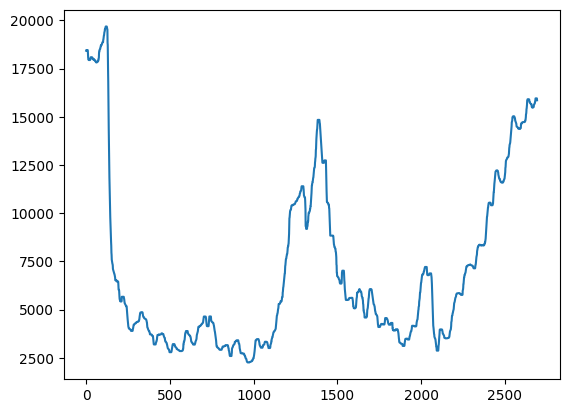

21


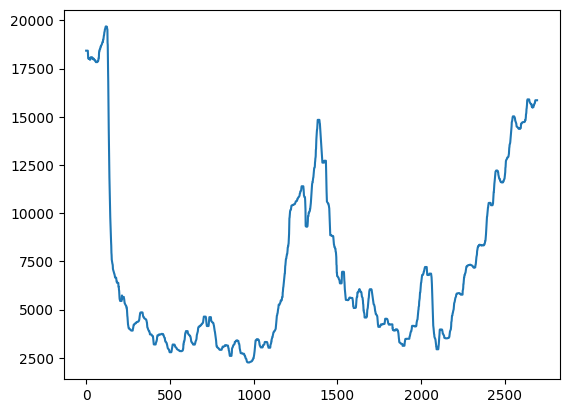

23


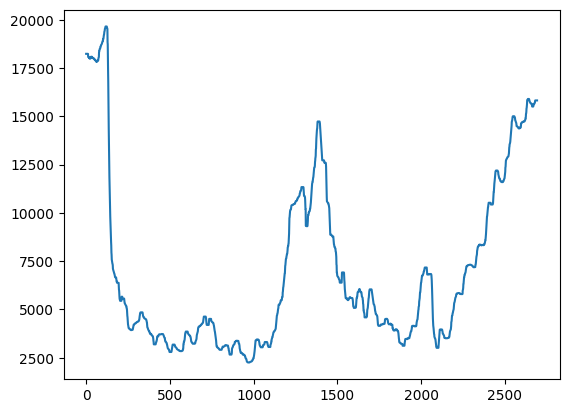

25


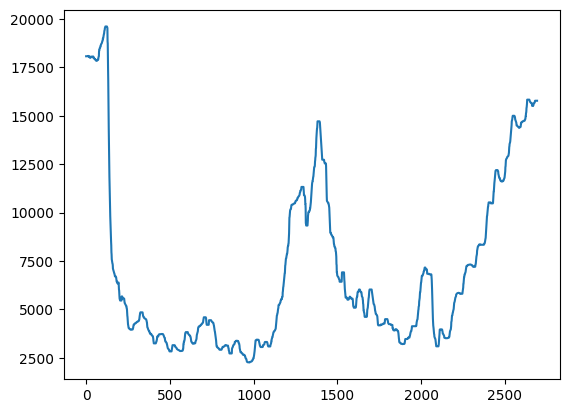

In [12]:
from scipy.signal import medfilt

kernel_size = [3,5,7,9,11,13,15,17,19,21,23,25]

for k in kernel_size:
    x_filtered = medfilt(x, kernel_size=k)
    print(k)
    plt.plot(x_filtered)
    plt.show()

### Method 3 using dx and ddx

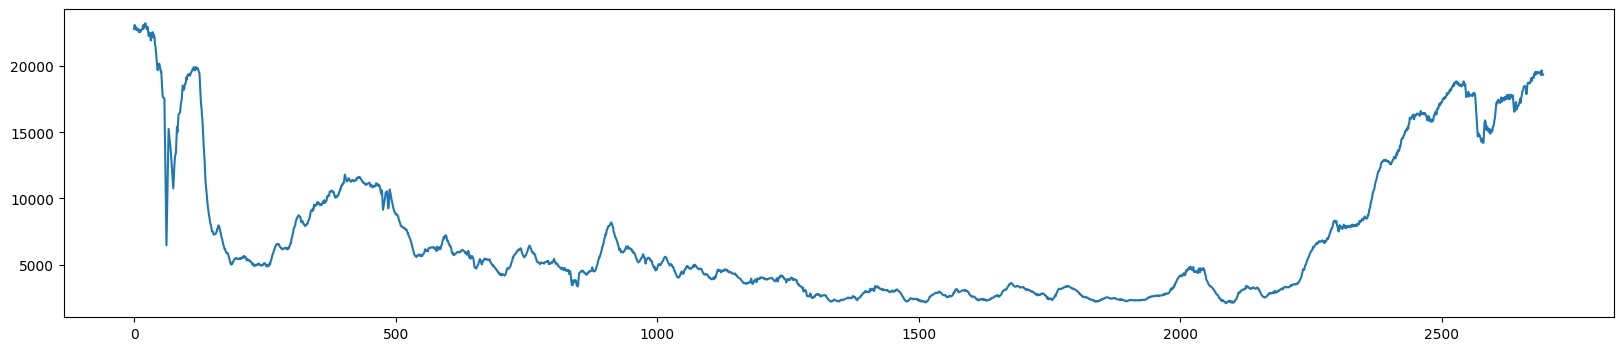

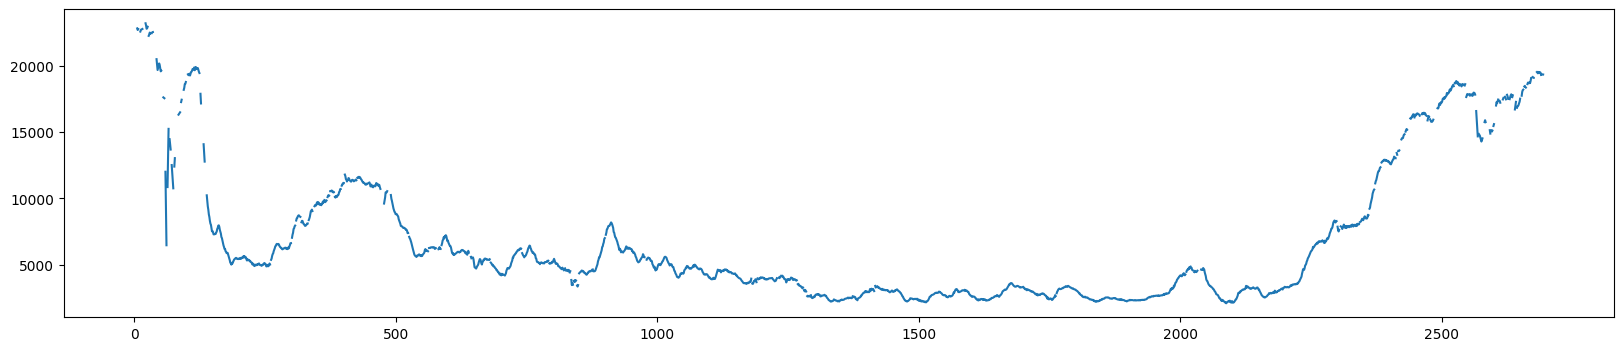

NaN gap lengths: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3]


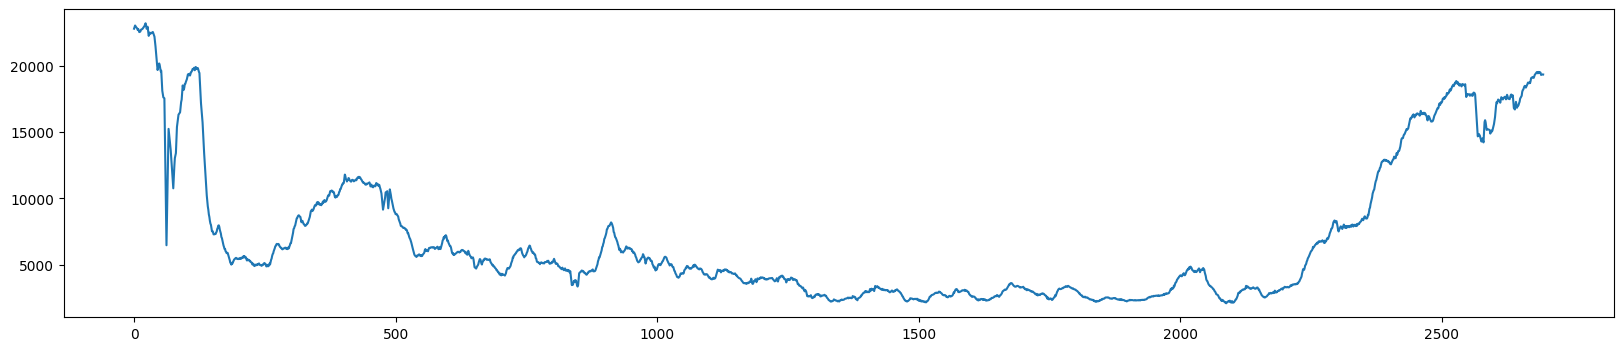

(2695,)


In [11]:
plt.figure(figsize=(20, 4))
plt.plot(x)
plt.show()

dx = np.diff(x, prepend=x[0])
ddx = np.diff(dx, prepend=dx[0])


mad_dx = np.nanmedian(np.abs(dx - np.nanmedian(dx)))
mad_ddx = np.nanmedian(np.abs(ddx - np.nanmedian(ddx)))

dx_thresh  = np.nanmedian(np.abs(dx))  + 2 * mad_dx
ddx_thresh = np.nanmedian(np.abs(ddx)) + 2 * mad_ddx

spike_mask = (np.abs(dx) > dx_thresh) & (np.abs(ddx) > ddx_thresh)



x_clean = x.copy()
x_clean[spike_mask] = np.nan

plt.figure(figsize=(20, 4))
plt.plot(x_clean)
plt.show()

from scipy.ndimage import label
nan_mask = np.isnan(x_clean)
labels, n = label(nan_mask)
gap_lengths = [np.sum(labels == i) for i in range(1, n + 1)]
print("NaN gap lengths:", sorted(gap_lengths))


# Method 1
# x_interp = pd.Series(x_clean).interpolate(limit=15).to_numpy()


# Method 2
to_interp = np.where(np.isnan(x_clean))[0]
known_x = np.where(~np.isnan(x_clean))[0]
known_y = x_clean[known_x]

x_interp = x_clean.copy()
x_interp[to_interp] = np.interp(to_interp, known_x, known_y)

plt.figure(figsize=(20, 4))
plt.plot(x_interp)
plt.show()

print(x_interp.shape)

### Method 4 using median area

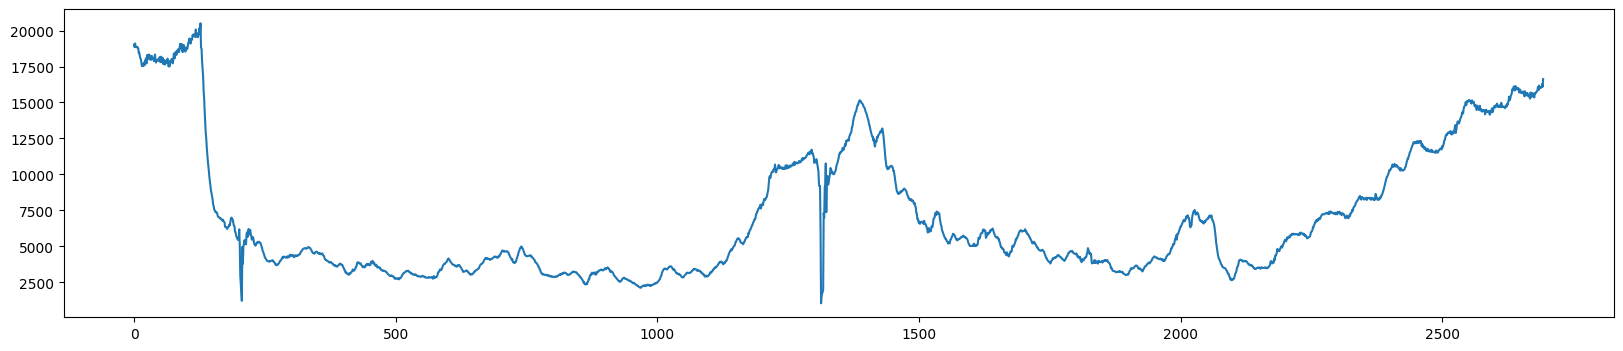

In [57]:
median_area = np.nanmedian(x)
mad_area = np.nanmedian(np.abs(x - median_area))
area_thresh = median_area + 0 * mad_area  # adjust k as needed

wide_peak_mask = x > area_thresh
x_clean = pd.Series(x).mask(wide_peak_mask).interpolate(limit=5).to_numpy()


plt.figure(figsize=(20, 4))
plt.plot(x_clean)
plt.show()

## Calcium DF Data

dict_keys(['__header__', '__version__', '__globals__', 'deltaF'])
(186, 3600)
Original shape: (186, 3600), Resampled shape: (186, 2700)
Plotting neuron 170


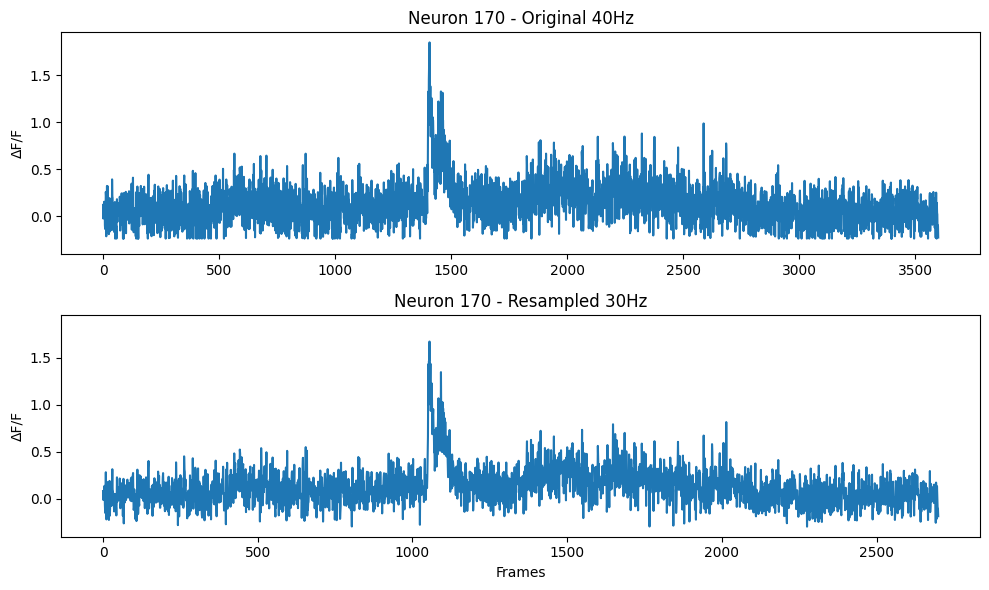

In [39]:
rec ='A42'

calcium_data = sio.loadmat(f'{data_dir}/Df/{session}/CaActivity/{rec}deltaf.mat')
print(calcium_data.keys())
deltaf = calcium_data['deltaF']
deltaf = deltaf[2:] # remove first 2 "neurons" which are background and neuropil
print(deltaf.shape) # 3600 frames = 40Hz * 90s

# Downsample parameters
fs_original = 40
fs_target = 30
up = 3
down = 4  # because 40*3/4 = 30

# Resample all neurons
deltaf_resampled = np.array([resample_poly(neuron, up, down) for neuron in deltaf])

print(f'Original shape: {deltaf.shape}, Resampled shape: {deltaf_resampled.shape}')

# Pick a random neuron to plot
neuron_idx = np.random.randint(0, deltaf.shape[0])
print(f'Plotting neuron {neuron_idx}')

# Plot in 2 rows
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False, sharey=True)

# Original 40Hz
axes[0].plot(deltaf[neuron_idx])
axes[0].set_title(f'Neuron {neuron_idx} - Original 40Hz')
axes[0].set_ylabel('ΔF/F')

# Resampled 30Hz
axes[1].plot(deltaf_resampled[neuron_idx])
axes[1].set_title(f'Neuron {neuron_idx} - Resampled 30Hz')
axes[1].set_xlabel('Frames')
axes[1].set_ylabel('ΔF/F')


plt.tight_layout()
plt.show()

In [100]:
deltaf_resampled.shape

(186, 2700)